Estudiante: Elmer Hernán Barquero Chaves C10896

# Parte I: Espectro y Reconstrucción usando FFT

La función con la que se va a trabajar es:

$$f(t) = sgn[sin(2\pi f t)] $$

In [88]:
import numpy as np
import matplotlib.pyplot as plt

In [89]:
freq = 1 # Frecuencia de oscilacion
t = np.linspace(-2.0,2.0,1000)
def math_function(frecuencia, tiempo):
	return np.sign(np.sin(2*np.pi*frecuencia*tiempo))

## Gráfico de la  función

Text(0.5, 1.0, 'Signal')

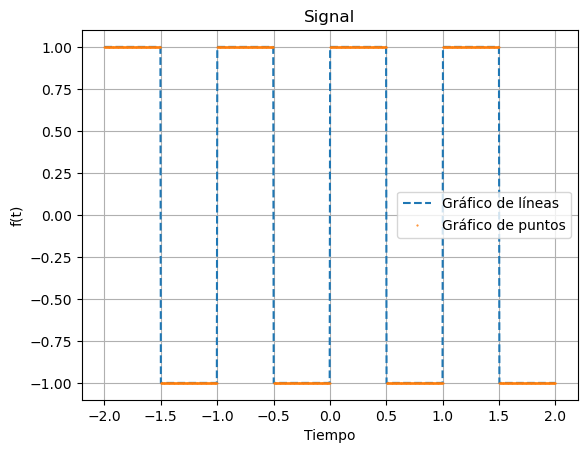

In [90]:
fig, ax = plt.subplots(1,1)
ax.plot(t, math_function(freq, t),'--', label = "Gráfico de líneas")
ax.plot(t, math_function(freq, t),'.', ms = 1, label = "Gráfico de puntos")

ax.grid()
ax.legend()

ax.set_xlabel("Tiempo")
ax.set_ylabel(r"f(t)")

ax.set_title("Signal")

## FFT en un solo período y con N = 1000

In [91]:
t_1p = np.linspace(-0.5,0.5,1000)

FFT_math_func = np.fft.fft(math_function(freq,t_1p), norm= "forward")

freq_math_func = np.fft.fftfreq(len(FFT_math_func), d=t_1p[1]-t_1p[0])

## Gráfico del Espectro

Text(0.5, 1.0, 'Fast Fourier Transformation of the signal')

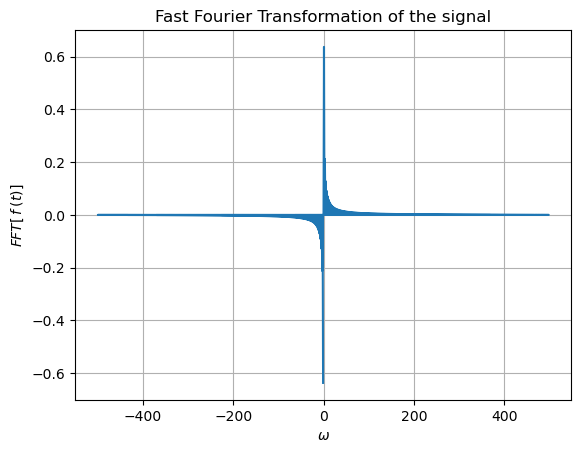

In [98]:
fig, ax = plt.subplots(1,1)
ax.plot(freq_math_func,np.imag(FFT_math_func),'-')

ax.grid()

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$FFT[\:f \: (t)]$")
ax.set_title("Fast Fourier Transformation of the signal")

#ax.set_xlim(-50,50)

## Conclusiones del modo de oscilación

No hay oscilación porque la frecuencia es cero. Hay muchas frecuencias de oscilación, cada una más cercana a cero???

## Reconstrucción de la señal original

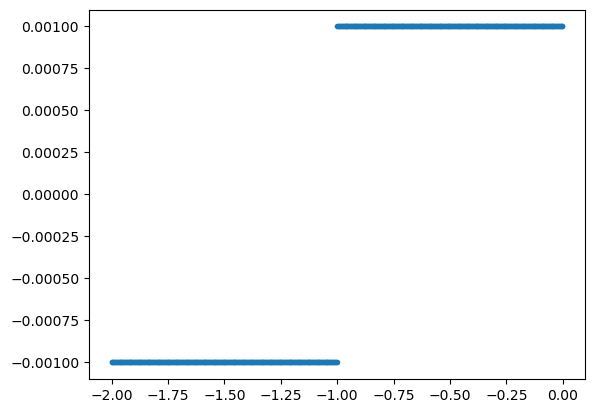

In [ ]:
# Esto esta raro
freq_mf_pos = freq_math_func[0:500]


mf_pos_recuper = np.fft.ifft(FFT_math_func[0:len(freq_mf_pos)], norm = "backFourierward")

fig, ax = plt.subplots(1,1)
ax.plot(t[:500],np.real(mf_pos_recuper),'.')

# Parte II: Ecuaciones Elípticas

## Código del docente

In [ ]:
# Esta función toma como argumentos el tamaño lineal de la grilla cuadrada,
# el valor del voltaje en la sección superior de la grilla y la tolerancia de convergencia 
def jacobi_relaxation(M, V, tolerance):
    # Primero creamos los arreglos 2-dimensionales de la grilla
    # Vamos a necesitar dos según la regla de Jacobi
    # Note que usamos M+1, debido a que debemos contener la condición de frontera
    # phi contiene inicialmente los valores iniciales. Vamos a utilizar ceros.
    phi = np.zeros((M + 1, M + 1), dtype=float)
    # Ahora tenemos que colocar la condición inicial.
    # Recuerde accesos de listas en np.ndarray
    ############################################################################
    # Aquí se edita las condiciones de frontera para el problema en cuestión
    ############################################################################
    #phi[20, 20:80] = V # Placa izquierda //// Con los ejes bien
    #phi[80, 20:80] = -1.0*V # Placa derecha
    
    phi[20:80, 20] = V # Placa izquierda //// Con el grafico bien
    phi[20:80,80] = -1.0*V # Placa derecha

    ############################################################################
    # phiprime se necesita para la iteración
    phiprime = np.zeros((M + 1, M + 1), dtype=float)
    # Iteración de Jacobi
    delta = 1.0
    its = 0
    while delta > tolerance:
        # Calculamos la iteración
        its += 1
        for i in range(M + 1):
            for j in range(M + 1):
                # Condición de frontera
                if i == 0 or i == M or j == 0 or j == M:
                    phiprime[i, j] = phi[i, j]
                # Iteración principal
                else:
                    #COMPLETE AQUÍ
                    phiprime[i,j] = 0.25*(phi[i+1,j] + phi[i-1,j] + phi[i, j+1]  + phi[i, j-1])
        # Calculamos la diferencia máxima con respecto a los valores anteriores
        delta = np.max(np.abs(phi - phiprime))
        # Ahora intercambiamos los arreglos para la nueva iteración
        # El nuevo phi es el phiprime
        temp = phi
        phi = phiprime
        # El nuevo phiprime es el phi viejo
        phiprime = temp
        
    return phi, its

In [106]:
jacobi_vals, iterations = jacobi_relaxation(100, 1.0, 1e-5)
print(iterations)

2627


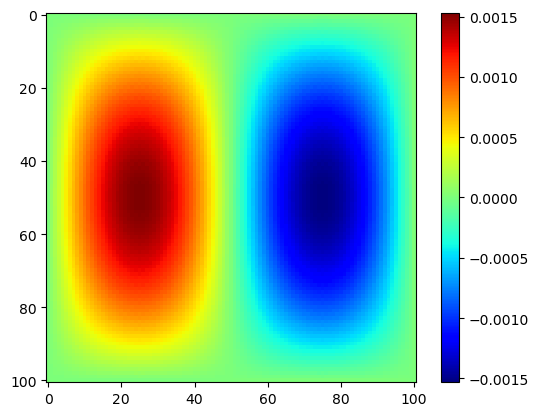

In [107]:
import matplotlib.cm as cm

fig, ax = plt.subplots()
cax = ax.imshow(jacobi_vals, cmap=cm.jet)  # Usar `cmap=cm.jet` en vez de `plt.jet()`
fig.colorbar(cax, ax=ax)  # Agregar una barra de color
plt.show()